# Tarea de Programación: AI Powered Request Dispatcher

En el mundo de los chats potenciados por AI y los modelos de lenguaje de gran escala, entregar una gran respuesta comienza por entender el **prompt** del usuario. Antes de que cualquier sistema pueda actuar, primero debe saber qué se le está preguntando. ¿Está el usuario haciendo una pregunta? ¿Quiere hacer una lluvia de ideas (*brainstorm*)? ¿O está solicitando un **summary**?

Este es el desafío fundamental que resolverás en esta tarea. Vas a construir un **AI Powered Request Dispatcher**, el primer paso esencial para cualquier sistema de AI avanzado. Tu modelo aprenderá a analizar y clasificar el **intent** detrás de cualquier solicitud de usuario, asegurando que se dirija a la herramienta especializada correcta para obtener una respuesta perfecta. Piénsalo como la "puerta de entrada inteligente" para una aplicación de AI potente.



Esta tarea te guiará a través de todo el proceso, desde el manejo de datos crudos hasta el **fine-tuning** de un modelo **pre-trained** sofisticado. Verás de primera mano cómo los conceptos fundamentales se unen para crear una herramienta práctica del mundo real.

Específicamente, realizarás los siguientes pasos:

* **Preparación de los Datos**: Comenzarás con el **Databricks Dolly 15k dataset**, una colección de instrucciones de alta calidad, y lo preprocesarás consolidando categorías y convirtiéndolas en etiquetas numéricas listas para el modelo.
* **Configuración de la Base**: Aprovecharás **DistilBERT**, un modelo **pre-trained** rápido y potente, junto con su **tokenizer** para que sirvan como el núcleo de tu **dispatcher**.
* **Ensamblaje del Flujo de Datos**: Construirás un **Dataset** de PyTorch personalizado para realizar la **tokenization** sobre la marcha y crearás **DataLoaders** para agrupar en **batches** y servir los datos al modelo eficientemente durante el entrenamiento.
* **Optimización del Proceso de Fine-Tuning**: Implementarás estrategias avanzadas para que tu entrenamiento sea más efectivo. Esto incluye calcular **class weights** para manejar datos desbalanceados y usar **partial freezing** para un entrenamiento de **fine-tuning** eficiente.
* **Entrenamiento y Evaluación**: Finalmente, unirás todo para entrenar tu **dispatcher**, analizarás su rendimiento con una **confusion matrix** y probarás sus capacidades en el mundo real con instrucciones nuevas y no vistas.

¡Comencemos a construir el núcleo inteligente de tu próxima gran aplicación de AI!

---
<a name='submission'></a>

<h4 style="color:green; font-weight:bold;">TIPS FOR SUCCESSFUL GRADING OF YOUR ASSIGNMENT:</h4>

* All cells are frozen except for the ones where you need to submit your solutions or when explicitly mentioned you can interact with it.

* In each exercise cell, look for comments `### START CODE HERE ###` and `### END CODE HERE ###`. These show you where to write the solution code. **Do not add or change any code that is outside these comments**.

* You can add new cells to experiment but these will be omitted by the grader, so don't rely on newly created cells to host your solution code, use the provided places for this.

* Avoid using global variables unless you absolutely have to. The grader tests your code in an isolated environment without running all cells from the top. As a result, global variables may be unavailable when scoring your submission. Global variables that are meant to be used will be defined in UPPERCASE.

* To submit your notebook for grading, first save it by clicking the 💾 icon on the top left of the page and then click on the `Submit assignment` button on the top right of the page.
---

## Table of Contents
- [Imports](#0)
- [1 - The Databricks Dolly 15k Dataset](#1)
    - [1.1 - Preparing the Instruction Data](#1-1)
- [2 - Setting Up the Foundation: DistilBERT](#2)
- [3. Assembling the Data Feed for Training](#3)
    - [3.1 - Creating a Custom PyTorch Dataset](#3-1)
        - **[Exercise 1 - InstructionDataset](#ex-1)**
    - [3.2 - Splitting Data for Training and Validation](#3-2)
    - [3.3 - Defining the Data Collator](#3-2)
        - **[Exercise 2 - create_data_collator](#ex-2)**
    - [3.4 - Constructing the Data Loaders](#3-4)
        - **[Exercise 3 - create_dataloaders](#ex-3)**
- [4 - Optimizing the Fine-Tuning Process](#4)
    - [4.1 - Addressing Class Imbalance](#4-1)
        - **[Exercise 4 - calculate_class_weights](#ex-4)**
    - [4.2 Configuring the Loss Function](#4-2)
    - [4.3 - Implementing an Efficient Fine-Tuning Strategy](#4-3)
        - - **[Exercise 5 - partially_freeze_bert_layers](#ex-5)**
- [5 - Training the Dispatcher](#5)
    - **[Exercise 6 - Configuring the Training Run](#5)**
- [6 - (Optional) Evaluating the Dispatcher](#6)
    - [6.1 - Analyzing Dispatcher Performance](#6-1)
    - [6.2 - Testing the Dispatcher on Unseen Instructions](#6-2)

<a name='0'></a>
## Imports

In [1]:
from pprint import pprint

import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import transformers

In [4]:
import helper_utils
#import unittests

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


<a name='1'></a>
## 1 - El Dataset Databricks Dolly 15k

Todo gran sistema de AI se construye sobre una base de datos de alta calidad. Para tu **AI Powered Request Dispatcher**, esa base es el [Databricks Dolly 15k](https://www.kaggle.com/datasets/snehilsanyal/databricks-dolly-15k-dataset), un **dataset** de seguimiento de instrucciones de código abierto creado por miles de empleados de Databricks. Contiene más de 15,000 pares de **prompt** y respuesta de alta calidad diseñados para hacer que los modelos de lenguaje sean más útiles e interactivos.

Para tu tarea de construir un **dispatcher**, te enfocarás en dos columnas clave: `instruction`, que contiene el **prompt** del usuario, y `category`, que describe el tipo de tarea que representa la instrucción (por ejemplo, `open_qa`, `summarization`, `creative_writing`).

#### Cómo se aumentó el Dataset

Para construir un **dispatcher** verdaderamente robusto, no puedes confiar solo en los datos originales. Es por eso que este **dataset** ha sido aumentado utilizando una técnica profesional llamada **back-translation**. Este proceso creó nuevos ejemplos de entrenamiento que son gramaticalmente diferentes pero semánticamente similares a los originales.



Esencialmente, cada instrucción se tradujo del inglés a 10 idiomas intermedios diferentes, como árabe, urdu y alemán, y luego se tradujo de nuevo al inglés. Este proceso generó nuevas oraciones con una redacción ligeramente distinta pero con el mismo significado central. Estas variaciones únicas se combinaron con los datos originales para crear un conjunto de ejemplos más grande y diverso para tu entrenamiento, haciendo crecer el **dataset** de aproximadamente 15,000 a 26,000 instrucciones.

Si estás interesado en los detalles específicos, puedes echar un vistazo a la función `augment_dataset_with_back_translation` que se utilizó para ello, la cual se encuentra en el archivo `helper_utils.py`.

Con este potente **augmented dataset** en mano, tu primera misión es preprocesarlo y darle forma para que sea el combustible perfecto para tu modelo.

<a name='1-1'></a>
### 1.1 - Preparación de los datos de instrucciones

Tu viaje desde los datos crudos hasta un modelo entrenado comienza con el primer paso del **preprocessing**. Aquí es donde limpias, refinas y estructuras tu **dataset** para asegurar que tu **dispatcher** aprenda de señales claras y significativas.

* Carga el **dataset** desde `"./databricks-dolly-15k-dataset/databricks-dolly_augmented.csv"` como un DataFrame y elimina cualquier fila incompleta para asegurar la integridad de los datos.

In [11]:
# Cargar el dataset y eliminar cualquier fila con valores faltantes para asegurar la calidad de los datos.
data_path = "./databricks-dolly-15k-dataset/databricks-dolly_augmented.csv"
df = pd.read_csv(data_path).dropna().reset_index(drop=True)

<br>

Primero, obtén una visión general del estado inicial del **dataset**. Al inspeccionar las **categorías únicas**, podrás entender los diferentes tipos de instrucciones que están presentes para que tu **dispatcher** pueda aprender de ellas.

In [8]:
# Obtener una lista de los nombres de categorías únicos de la columna 'category'.
unique_categories = df['category'].unique().tolist()

In [9]:
# Imprimir la lista de categorías únicas para ver el estado inicial.
print("Categorías iniciales en el dataset:\n")
pprint(unique_categories)

Categorías iniciales en el dataset:

['closed_qa',
 'classification',
 'open_qa',
 'information_extraction',
 'brainstorming',
 'general_qa',
 'summarization',
 'creative_writing']


<br>

Un vistazo rápido a las primeras filas confirmará que tus datos se han cargado correctamente y te dará una idea de la estructura con la que trabajarás.

In [10]:
# EDITABLE CELL

df.head(10)

,instruction,category
0,When did Virgin Australia start operating?,closed_qa
1,Which is a species of fish? Tope or Rope,classification
2,Why can camels survive for long without water?,open_qa
3,"Alice's parents have three daughters: Amy, Jes...",open_qa
4,When was Tomoaki Komorida born?,closed_qa
5,If I have more pieces at the time of stalemate...,information_extraction
6,"Given a reference text about Lollapalooza, whe...",closed_qa
7,Who gave the UN the land in NY to build their HQ,open_qa
8,Why mobile is bad for human,brainstorming
9,Who was John Moses Browning?,information_extraction


<br>

En un proyecto del mundo real, a menudo necesitas tomar decisiones estratégicas sobre tus clases objetivo. El **dataset** original tiene varias categorías muy granulares. Para crear un **dispatcher** más enfocado y efectivo para esta tarea, consolidarás las categorías similares. Esta práctica común simplifica la tarea de clasificación y puede llevar a un modelo más robusto.



* Fusionarás todos los tipos de preguntas y respuestas en un único objetivo llamado `q_and_a`, y combinarás `information_extraction` con `summarization` para crear una nueva categoría de `information_distillation`. Esto simplifica el conjunto de objetivos de enrutamiento que tu **dispatcher** necesita aprender.

In [12]:
# Crear un diccionario de mapeo para definir cómo deben fusionarse las categorías.
# Las llaves son los nombres de las categorías antiguas y los valores son los nuevos nombres consolidados.
category_map = {
    "general_qa": "q_and_a",
    "open_qa": "q_and_a",
    "closed_qa": "q_and_a",
    "information_extraction": "information_distillation",
    "summarization": "information_distillation"
}

# Usar el método replace() en la columna 'category' para aplicar el mapeo.
df['category'] = df['category'].replace(category_map)

<br>

Con tus categorías finales definidas, es hora de traducirlas a un formato que el modelo pueda entender. Convertirás tus categorías de texto en **labels** numéricos. También crearás un diccionario de mapeo inverso, una herramienta que te permitirá convertir el **output** numérico del modelo de nuevo en predicciones legibles por humanos más adelante.

In [13]:
# Obtener un array de los nombres de categorías únicos y consolidados.
unique_categories = df['category'].unique()

# Crear un diccionario para mapear cada nombre de categoría a un ID entero único.
cat2id = {category: i for i, category in enumerate(unique_categories)}

# Crear la nueva columna 'label' en el DataFrame aplicando el mapeo.
# La función .map() convierte eficientemente cada nombre de categoría a su ID entero correspondiente.
df['label'] = df['category'].map(cat2id)

# Crear el mapeo inverso de ID entero de vuelta al nombre de la categoría.
id2cat = {id: category for category, id in cat2id.items()}

In [17]:
cat2id, id2cat

({'q_and_a': 0,
  'classification': 1,
  'information_distillation': 2,
  'brainstorming': 3,
  'creative_writing': 4},
 {0: 'q_and_a',
  1: 'classification',
  2: 'information_distillation',
  3: 'brainstorming',
  4: 'creative_writing'})

<br>

Para finalizar esta etapa de tu **pipeline** de datos, extraerás los componentes principales —los textos de `instruction` y sus correspondientes **labels** numéricos— en listas dedicadas, listas para la siguiente fase.

In [20]:
# Extraer las columnas 'instruction' y 'label' en listas
texts = df['instruction'].tolist()
labels = df['label'].tolist()

<br>

Realiza una verificación final. Un vistazo rápido a la distribución de clases debería confirmarte que los pasos de **preprocessing** fueron exitosos y mostrarte el número final de muestras para cada categoría.

In [21]:
print(f"Total samples for classification: {len(texts)}\n")
print("Class distribution:")

# Iterar a través del mapeo de categoría a ID para informar sobre cada clase.
for category, label_id in cat2id.items():
    count = labels.count(label_id)
    print(f"  - label {label_id}: {category:<25} {count} samples")

Total samples for classification: 26238

Class distribution:
  - label 0: q_and_a                   13243 samples
  - label 1: classification            3918 samples
  - label 2: information_distillation  4681 samples
  - label 3: brainstorming             3113 samples
  - label 4: creative_writing          1283 samples


<br>

Echa un vistazo al producto final de tu **pipeline** de **preprocessing**: datos limpios y etiquetados. Este es exactamente el formato que tu **Dataset** y **DataLoaders** utilizarán para alimentar al **dispatcher** durante el entrenamiento.

* Siéntete libre de cambiar los valores de `num_samples` y `random_state`.

In [22]:
# CELDA EDITABLE

# Establecer el número de muestras aleatorias a mostrar, y el random_state.
num_samples = 10
random_state = 25

# Mostrar una muestra de pares de instruction y label.
display(df[['instruction', 'label']].sample(num_samples, random_state=random_state).style.hide(axis="index"))

instruction,label
Who is the best NBA player of all time?,0
Where is Seinäjoki City Hall?,2
How difficult is it to learn how to juggling?,0
"Identify the bird from the list: Queensbury, Kingfisher, Bishopsgate",1
Give me some strategies to prevent procrastination,3
Who won the 149 boat race?,0
Plan a weekend vacation to Madrid and mention several specific places that you would visit and how you would travel in the city,4
"Classify each of the following as characters from books J.K. Rowling has written or books that Suzanne Collins has written: Peeta Mellark, Katness Everdeen, Effie Trinket, Seneca Crane, Lucy Gray, Cinna, Harry Potter, Severus Snape, Hermione Granger, Albus Dumbledore",1
"How did Andy Warhol create the ""piss paintings""?",0
How far is the town of Warsaw?,2


<a name='2'></a>
## 2 - Configuración de la Base: DistilBERT

Con tus datos perfectamente preparados, es hora de seleccionar el motor para tu **dispatcher**. En el **NLP** moderno, rara vez se construye desde cero. En su lugar, aprovecharás una potente base **pre-trained** para darle a tu proyecto una ventaja inicial masiva.

Tu elección es [DistilBERT](https://huggingface.co/docs/transformers/en/model_doc/distilbert): una versión ligera, eficiente y potente del BERT original. Para un **dispatcher** que necesita ser rápido y reactivo, DistilBERT es el punto de partida perfecto.



Por supuesto, un modelo es tan bueno como su comprensión del lenguaje. Junto con el modelo, cargarás su **tokenizer** correspondiente. Este componente integral es el responsable de traducir tus instrucciones de texto crudo al formato numérico que DistilBERT entiende, actuando como el puente entre el lenguaje humano y el "cerebro" del modelo.

* Descarga el modelo **pre-trained** y su **tokenizer**.

In [23]:
model_name="distilbert-base-uncased"
model_path="./distilbert-local-base"

# Ensure the model is downloaded
helper_utils.download_bert(model_name, model_path)

Base model 'distilbert-base-uncased' already available at ./distilbert-local-base


<br>

* Carga el modelo DistilBERT y su **tokenizer** en memoria, configurando oficialmente el núcleo de tu **AI dispatcher**.

**Nota**: Verás un aviso (*warning*) indicando que algunos pesos fueron "recién inicializados" (*newly initialized*). Esto es normal. Confirma que has cargado con éxito la base **pre-trained** de DistilBERT y que le has acoplado un nuevo **classification head** sin entrenar.

In [24]:
# Obtener el número de clases únicas de la columna 'category'.
num_classes = df['category'].nunique()

# Cargar el modelo DistilBERT pre-trained y su tokenizer desde la ruta local.
bert_model, bert_tokenizer = helper_utils.load_bert(model_path, 
                                                    num_classes=num_classes
                                                   )

Loading base model from ./distilbert-local-base and adding a new head with 5 classes.



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: ./distilbert-local-base
Key                   | Status  | 
----------------------+---------+-
pre_classifier.bias   | MISSING | 
classifier.weight     | MISSING | 
pre_classifier.weight | MISSING | 
classifier.bias       | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model and tokenizer loaded successfully.


<a name='3'></a>
## 3. Ensamblaje del Flujo de Datos para el Entrenamiento
El motor de tu modelo (DistilBERT) está listo y tu combustible (los datos preprocesados) está refinado. Ahora, necesitas construir el **pipeline** que los conecte.

Esta sección trata sobre la creación de un flujo de datos eficiente y automatizado para tu **dispatcher**. Construirás los componentes esenciales de PyTorch: un **Dataset** personalizado y potentes **DataLoaders**, que se encargarán de la **tokenization**, el agrupamiento en **batches** y el **shuffling** (mezclado), asegurando un proceso de entrenamiento fluido y eficiente.

<a name='3-1'></a>
### 3.1 - Creación de un Dataset de PyTorch Personalizado

El corazón de tu **data pipeline** será un `InstructionDataset` personalizado. Este no será solo un simple contenedor de datos, sino un componente inteligente que realizará la **tokenization** sobre la marcha.

Cada vez que el bucle de entrenamiento solicite una muestra, tu **Dataset** tomará el texto crudo, lo tokenizará instantáneamente con tu **tokenizer** de DistilBERT y lo emparejará con su **label** correcto. Este procesamiento "justo a tiempo" (*just-in-time*) es una práctica eficiente y estándar en los **pipelines** modernos de **NLP**.



<a name='ex-1'></a>
### Ejercicio 1 - InstructionDataset

Ahora es tu turno de construir este componente central. Implementa la clase `InstructionDataset`, que servirá como el plano (*blueprint*) para preparar cada muestra individual para tu modelo.

**Tu Tarea**:

* **Dentro del método `__init__`:**
    * Este método configura el **dataset**. Necesitas almacenar las listas de `texts` y `labels`, junto con el `tokenizer`, para que puedan usarse más adelante.
    * Asígnalos tal como se pasan a sus correspondientes atributos de instancia.
* **Dentro del método `__getitem__`**:
    * **Obtener los datos**: Consigue el `text` y el `label` específicos para el índice dado (`idx`).
    * **Tokenizar el texto**: Usa `self.tokenizer` para convertir el **string** de `text` crudo en un `encoding` procesado. Debes establecer `truncation` en `True` y `max_length` en `512`.
        * Este **encoding** será un diccionario que contiene `input_ids` y `attention_mask`.
    * **Agregar el label**: Agrega el `label` entero al diccionario de **encoding** con la clave `'labels'`. Es importante convertir este **label** en un `torch.tensor` de tipo `torch.long`.

<details>
<summary><b><font color="green">Pistas adicionales de código (Haz clic para expandir si te quedas atascado)</font></b></summary>

Si estás atascado, aquí tienes un desglose más detallado.

**Para el método __init__:**
* Este es un constructor estándar de Python. Solo estás guardando los argumentos para su uso posterior.
* Por ejemplo, la primera línea será `self.texts = texts`. Sigue este patrón para `labels` y `tokenizer`.

**Para el método __getitem__**:
* **Obtener los datos**: Usa el indexado de listas estándar para obtener un elemento de tus listas almacenadas (ej., `text = self.texts[idx]`).

* **Tokenizar**: El **tokenizer** es un objeto llamable (*callable*). Pasas el **string** del `text` y los parámetros `truncation` y `max_length`. La llamada se verá así:
    * > `encoding = llamar al tokenizer con (el texto, la opción truncation en True, y la opción max_length en 512)`

* **Agregar el label**: Este es un paso de dos partes. Primero, accede a la clave del diccionario: `encoding['labels'] = ....` El valor que asignes debe ser el **label** convertido al tipo de tensor correcto. Se verá así:
    * > `encoding['labels'] = crear un nuevo torch.tensor(a partir del label, y establecer el dtype al tipo long de torch)`

</details>

In [27]:
# GRADED CLASS: InstructionDataset

class InstructionDataset(Dataset):
    """
    Dataset de PyTorch personalizado para la clasificación de texto.

    Esta clase Dataset almacena textos crudos y sus labels correspondientes. Está
    diseñada para trabajar eficientemente con un tokenizer de Hugging Face, realizando
    la tokenization sobre la marcha para cada muestra cuando es solicitada.

    Args:
        texts (list[str]): Una lista de strings de texto crudo.
        labels (list[int]): Una lista de labels enteros correspondientes a los textos.
        tokenizer: Una instancia de un tokenizer de Hugging Face utilizada para procesar texto.
    """
    def __init__(self, texts, labels, tokenizer):
        
        ### START CODE HERE ###
        
        # Almacenar la lista de strings de texto crudo
        self.texts = texts
        # Almacenar la lista de labels enteros
        self.labels = labels
        # Almacenar la instancia del tokenizer que procesará el texto
        self.tokenizer = tokenizer

        ### END CODE HERE ###

    def __len__(self):
        """Retorna el número total de muestras en el dataset."""
        return len(self.texts)

    def __getitem__(self, idx):
        """
        Recupera y procesa una muestra del dataset.

        Para un índice dado, este método obtiene el texto y label correspondientes,
        tokeniza el texto y retorna un diccionario de tensores.

        Args:
            idx (int): El índice de la muestra a recuperar.

        Returns:
            dict: Un diccionario que contiene los inputs tokenizados ('input_ids',
                  'attention_mask') y los 'labels' como tensores.
        """

        ### START CODE HERE ###
        
        # Obtener el texto crudo y el label para el índice especificado
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenizar el texto. Esta única llamada maneja la limpieza, tokenization,
        # conversión a IDs numéricos y truncation.
        # Establecer `truncation` como `True` y `max_length` como 512
        encoding = self.tokenizer(text, truncation=True, max_length=512)

        # Agregar el label al diccionario de encoding y convertirlo a un tensor
        # Establecer `dtype` como `torch.long`
        encoding['labels'] = torch.tensor(label, dtype=torch.long)

        ### END CODE HERE ###

        return encoding

In [28]:
# Inicializar el dataset para verificar
verify_class = InstructionDataset(texts, labels, bert_tokenizer)

print(f"Dataset inicializado con un total de {len(verify_class)} muestras.")
print("-" * 50)


# Mostrar las primeras 3 instrucciones y sus labels correspondientes
print("Mostrando las primeras 3 instrucciones y labels de tus datos:\n")
for i in range(3):
    print(f"Instrucción: {verify_class.texts[i]}")
    print(f"Label:       {verify_class.labels[i]}\n")
print("-" * 50)

Dataset inicializado con un total de 26238 muestras.
--------------------------------------------------
Mostrando las primeras 3 instrucciones y labels de tus datos:

Instrucción: When did Virgin Australia start operating?
Label:       0

Instrucción: Which is a species of fish? Tope or Rope
Label:       1

Instrucción: Why can camels survive for long without water?
Label:       0

--------------------------------------------------


#### Expected Output:

```
Dataset initialized with 26238 total samples.
--------------------------------------------------
Displaying the first 3 instructions and labels from your data:

Instruction: When did Virgin Australia start operating?
Label:       0

Instruction: Which is a species of fish? Tope or Rope
Label:       1

Instruction: Why can camels survive for long without water?
Label:       0

--------------------------------------------------
```

In [ ]:
# Test your code!
unittests.exercise_1(InstructionDataset)

<a name='3-2'></a>
### 3.2 - División de datos para entrenamiento y validación

Con tu clase `InstructionDataset` definida, crea una instancia que contenga todo tu **dataset** preprocesado.

Sin embargo, para construir un modelo confiable, debes evaluar su rendimiento de manera honesta. Esto significa probarlo con datos que nunca haya visto durante el entrenamiento. Un modelo que funciona bien con los datos de entrenamiento pero falla con los datos nuevos no es realmente inteligente; simplemente ha memorizado las respuestas.

Por lo tanto, un paso importante en cualquier **machine learning pipeline** es particionar los datos. Dividirás tu **dataset** completo en un **training set** grande para enseñar al modelo, y un **validation set** más pequeño para probar de forma rigurosa e imparcial su capacidad de generalización.

* Crea el objeto `full_dataset` pasando tus `texts`, `labels` y `bert_tokenizer` preparados a la clase `InstructionDataset`.

In [29]:
# Create the full dataset
full_dataset = InstructionDataset(texts, labels, bert_tokenizer)

* Dividir `full_dataset` completo en un 80% para el training set y un 20% para el validation set.

In [30]:
# Dividir el dataset completo en un 80% para el training set y un 20% para el validation set.
train_dataset, val_dataset = helper_utils.create_dataset_splits(
    full_dataset, 
    train_split_percentage=0.8
)

# Imprimir el número de muestras en cada conjunto para verificar la división.
print(f"Muestras de entrenamiento:   {len(train_dataset)}")
print(f"Muestras de validación:      {len(val_dataset)}")

Muestras de entrenamiento:   20990
Muestras de validación:      5248


<a name='3-3'></a>
### 3.3 - Definición del Data Collator

Tu **data pipeline** está tomando forma. Tienes tus **datasets**, pero hay un desafío práctico que resolver antes de poder crear **batches**: tus instrucciones tokenizadas tienen diferentes longitudes; en otras palabras, cada oración tiene un número diferente de palabras. Para entrenar tu modelo eficientemente, cada **batch** de datos debe ser un tensor uniforme. Para manejar esto, necesitas un componente que pueda aplicar **padding** dinámicamente a las secuencias más cortas para que cada instrucción en el **batch** coincida con la longitud de la más larga. Esto asegurará que siempre se alimenten tensores rectangulares con la forma perfecta a tu **dispatcher**. Necesitas un **data collator**.

<a name='ex-2'></a>
### Ejercicio 2 - create_data_collator

Tu siguiente tarea es implementar la función `create_data_collator`, que crea este componente esencial de **padding** para tu **data pipeline**.

**Tu Tarea**:

* Dentro de la función, necesitas crear una instancia de la clase `transformers.DataCollatorWithPadding`.
* Durante la inicialización, debes pasar el `tokenizer` al parámetro `tokenizer` de la clase.

<details>
<summary><b><font color="green">Pistas adicionales de código (Haz clic para expandir si te quedas atascado)</font></b></summary>

Este ejercicio consiste en inicializar una clase de la librería `transformers` y asignarla a la variable `collator`.

La llamada se verá así:

> `collator = crear una instancia de la clase DataCollatorWithPadding, y pasar el tokenizer a su parámetro 'tokenizer'`

</details>

In [35]:
# GRADED FUNCTION: create_data_collator

def create_data_collator(tokenizer):
    """
    Inicializa y devuelve un data collator para padding dinámico.
    
    Args:
        tokenizer: Una instancia de un tokenizer de Hugging Face.
    
    Returns:
        collator: Una instancia de transformers.DataCollatorWithPadding.
    """

    ### START CODE HERE ###
    
    # Inicializar el data collator
    collator = transformers.DataCollatorWithPadding(tokenizer=tokenizer)

    ### END CODE HERE ###
    
    return collator

In [36]:
# Crear algunas muestras tokenizadas con diferentes longitudes para simular un batch
sample_1 = bert_tokenizer("This is a short sentence.")
sample_1['labels'] = torch.tensor(0)
sample_2 = bert_tokenizer("This particular sentence is quite a bit longer.")
sample_2['labels'] = torch.tensor(1)
manual_batch = [sample_1, sample_2]

# Inicializar el data collator
verify_function = create_data_collator(bert_tokenizer)

# Imprimir los 'input_ids' originales y sin padding para cada muestra
print("--- Before Collation (Original input_ids) ---")
for i, sample in enumerate(manual_batch):
    print(f"Sample {i+1} 'input_ids': {sample['input_ids']}")

print("\n--- After Collation (Padded and batched) ---")
# Pasar la lista de muestras al collator e inspeccionar el resultado
collated_batch = verify_function(manual_batch)

# Imprimir directamente el tensor final
print(collated_batch['input_ids'])

--- Before Collation (Original input_ids) ---
Sample 1 'input_ids': [101, 2023, 2003, 1037, 2460, 6251, 1012, 102]
Sample 2 'input_ids': [101, 2023, 3327, 6251, 2003, 3243, 1037, 2978, 2936, 1012, 102]

--- After Collation (Padded and batched) ---
tensor([[ 101, 2023, 2003, 1037, 2460, 6251, 1012,  102,    0,    0,    0],
        [ 101, 2023, 3327, 6251, 2003, 3243, 1037, 2978, 2936, 1012,  102]])


#### Expected Output:

```
--- Before Collation (Original input_ids) ---
Sample 1 'input_ids': [101, 2023, 2003, 1037, 2460, 6251, 1012, 102]
Sample 2 'input_ids': [101, 2023, 3327, 6251, 2003, 3243, 1037, 2978, 2936, 1012, 102]

--- After Collation (Padded and batched) ---
tensor([[ 101, 2023, 2003, 1037, 2460, 6251, 1012,  102,    0,    0,    0],
        [ 101, 2023, 3327, 6251, 2003, 3243, 1037, 2978, 2936, 1012,  102]])
```

In [ ]:
# Test your code!
unittests.exercise_2(create_data_collator)

<br>

¡Gran trabajo! Con tu función correctamente definida, crea la instancia oficial de `data_collator`. Este componente ya está listo para ser conectado a la etapa final de tu **data pipeline**.

In [37]:
data_collator = create_data_collator(bert_tokenizer)

<a name='3-4'></a>
### 3.4 - Construcción de los Data Loaders

Has llegado a la etapa final de ensamblaje de tu **pipeline** de datos. Tienes los datos refinados (`Dataset`) y el mecanismo de **padding** (`DataCollator`). Ahora necesitas unirlos con los `DataLoaders`.

Estos potentes iteradores son los "caballos de batalla" que entregarán **batches** perfectamente colacionados y mezclados a tu modelo, completando el puente automatizado entre tus datos crudos y el bucle de entrenamiento de tu **dispatcher**.


<a name='ex-3'></a>
### Ejercicio 3 - create_dataloaders

Implementa la función `create_dataloaders` para producir dos instancias de `DataLoader`.

Tu tarea final para la sección del **pipeline** de datos es implementar la función `create_dataloaders`, que construye estos `DataLoader` tanto para tu conjunto de entrenamiento como para el de validación.

**Tu Tarea**:

* **Crear el `train_loader`**:
    * Instancia un `DataLoader` para el `train_dataset`.
    * Debes pasar el `train_dataset`, `batch_size` y `collate_fn` a los parámetros correctos.
    * Establece `shuffle` en `True`.
* **Crear el `val_loader`**:
    * Instancia un `DataLoader` para el `val_dataset`.
    * Debes pasar el `val_dataset`, `batch_size` y `collate_fn` a los parámetros correctos.
    * Establece `shuffle` en `False`.

<details>
<summary><b><font color="green">Pistas adicionales de código (Haz clic para expandir si te quedas atascado)</font></b></summary>

Crearás dos instancias de la clase `DataLoader`, una para entrenamiento y otra para validación.

**Para el `train_loader`**:
* Necesitas llamar a la clase `DataLoader` y proporcionar los argumentos correctos.
* El primer argumento es el dataset mismo (`train_dataset`).
* Los otros argumentos se pasan por nombre: `batch_size=...`, `shuffle=...`, y `collate_fn=....` Recuerda establecer `shuffle` en `True`.

**Para el `val_loader`**:
* Esto es casi idéntico a la creación del `train_loader`.
* La diferencia clave es que usarás el `val_dataset` y, lo más importante, debes establecer `shuffle` en `False`.

</details>

In [38]:
# GRADED FUNCTION: create_dataloaders

def create_dataloaders(train_dataset, val_dataset, batch_size, collate_fn):
    """
    Crea y devuelve instancias de DataLoader para los conjuntos de entrenamiento y validación.
    
    Args:
        train_dataset (Dataset): El dataset de entrenamiento.
        val_dataset (Dataset): El dataset de validación.
        batch_size (int): El número de muestras por batch.
        collate_fn (callable): La función para fusionar una lista de muestras y formar un mini-batch.
    
    Returns:
        tuple: Una tupla que contiene el DataLoader de entrenamiento y el DataLoader de validación.
    """

    ### START CODE HERE ###
    
    # Crear el DataLoader para el conjunto de entrenamiento
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )

    
    # Crear el DataLoader para el conjunto de validación
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    ### END CODE HERE ###

    return train_loader, val_loader

In [39]:
# Crear los DataLoaders
batch_size = 16
verify_function = create_dataloaders(train_dataset, val_dataset, batch_size, data_collator)

# Inspeccionar el Train Loader
first_train_batch = next(iter(verify_function[0]))
print("Forma de cada tensor en el batch de entrenamiento:")
for key, value in first_train_batch.items():
    print(f"  - {key}: {value.shape}")

print()

# Inspeccionar el Validation Loader 
first_val_batch = next(iter(verify_function[1]))
print("Forma de cada tensor en el batch de validación:")
for key, value in first_val_batch.items():
    print(f"  - {key}: {value.shape}")

Forma de cada tensor en el batch de entrenamiento:
  - input_ids: torch.Size([16, 52])
  - attention_mask: torch.Size([16, 52])
  - labels: torch.Size([16])

Forma de cada tensor en el batch de validación:
  - input_ids: torch.Size([16, 35])
  - attention_mask: torch.Size([16, 35])
  - labels: torch.Size([16])


#### Expected Output: 
##### (value of "x" below will vary for each execution):

```
Shape of each tensor in the train batch:
  - input_ids: torch.Size([16, x])
  - attention_mask: torch.Size([16, x])
  - labels: torch.Size([16])

Shape of each tensor in the validation batch:
  - input_ids: torch.Size([16, x])
  - attention_mask: torch.Size([16, x])
  - labels: torch.Size([16])
```

In [ ]:
# Test your code!
unittests.exercise_3(create_dataloaders)

<br>

¡Fantástico! Tu función `create_dataloaders` está funcionando a la perfección, produciendo **batches** con la forma adecuada. Con esto, tu **data pipeline** está oficialmente completo. Crea el `train_loader` y el `val_loader` finales que alimentarán a tu modelo durante su entrenamiento.

In [40]:
batch_size = 32
train_loader, val_loader = create_dataloaders(train_dataset, val_dataset, batch_size, data_collator)

<a name='4'></a>
## 4 - Optimización del proceso de Fine-Tuning

Con un pipeline de datos robusto en marcha, ahora puedes centrar tu atención en el proceso de entrenamiento en sí. Simplemente entregar datos a un modelo no es suficiente. Los modelos de nivel profesional se entrenan con estrategias inteligentes y eficientes.

En esta sección, implementarás dos técnicas potentes para elevar nuestro proceso de ajuste fino (**fine-tuning**): **pérdida ponderada** (weighted loss) para manejar el desbalance de clases y **congelación parcial** (partial freezing) para un entrenamiento más rápido y eficiente.

<a name='4-1'></a>
### 4.1 - Abordando el desbalance de clases

Un desafío común en los conjuntos de datos del mundo real es el **desbalance de clases**. Algunas categorías tienen naturalmente más datos que otras. Si se ignora, tu modelo podría sesgarse, favoreciendo los tipos de instrucciones más comunes y rindiendo mal en los más raros.

Para construir un dispatcher justo y confiable, debes abordar esto directamente. Calcularás los **pesos de clase** (class weights), los cuales ajustarán estratégicamente tu función de pérdida. Esto le indica al modelo que preste atención adicional a las categorías subrepresentadas, asegurando que aprenda a clasificar todos los tipos de instrucciones con la misma destreza.

<a name='ex-4'></a>
### Ejercicio 4 - calculate_class_weights

Tu tarea es implementar la función `calculate_class_weights` que calcula estos pesos de clase.

**Tu Tarea**:

* **Calcular Pesos**:
    * Usa la función `compute_class_weight` de `sklearn.utils.class_weight`.
    * Debes establecer `class_weight` en `'balanced'` para que la función calcule automáticamente los pesos.
    * Pasa las etiquetas de clase únicas al parámetro `classes`. Para esto, usarás <code>[np.unique()](https://numpy.org/doc/2.1/reference/generated/numpy.unique.html)</code>.
    * Pasa la lista completa de etiquetas de entrenamiento al parámetro `y`.
* **Convertir a Tensor:**
    * La función `compute_class_weight` devuelve un array de NumPy. Necesitas convertir este array en un tensor de PyTorch.
    * Asegúrate de que el tipo de datos del tensor sea `torch.float`.

<details>
<summary><b><font color="green">Pistas adicionales de código (Haz clic para expandir si te quedas atascado)</font></b></summary>

Esta función implica una llamada a la función principal y luego una conversión de tipo.

**Para calcular los pesos:**
* Llamarás a `compute_class_weight` y asignarás el resultado a la variable `class_weights`.
* La llamada a la función se verá así:
    * > `class_weights = llamar a compute_class_weight con (class_weight establecido en 'balanced', classes establecido llamando a np.unique() sobre la lista de etiquetas, e y establecido como la lista completa de etiquetas)`

**Para convertir a un tensor**:
* Usarás `torch.tensor()` para convertir el array de NumPy `class_weights`.
* La llamada seguirá esta estructura:
    * > `class_weights_tensor = crear un nuevo torch.tensor(a partir de class_weights, y establecer el dtype al tipo float de torch)`

</details>

In [41]:
# GRADED FUNCTION: calculate_class_weights

def calculate_class_weights(train_dataset, device):
    """
    Calcula los pesos de clase para manejar datasets desbalanceados.
    
    Args:
        train_dataset (torch.utils.data.Subset): 
            El dataset de entrenamiento, se espera que sea un objeto Subset que contiene 
            índices al dataset original.
        device (torch.device): 
            El dispositivo (ej., 'cuda' o 'cpu') donde se colocará el tensor final.
    
    Returns:
        torch.Tensor: Un tensor 1D de pesos de clase.
    """
    # Extraer todos los labels del conjunto de entrenamiento para calcular los pesos de clase
    train_labels_list = [train_dataset.dataset.labels[i] for i in train_dataset.indices]

    ### START CODE HERE ###

    # Usar la utilidad de scikit-learn para calcular automáticamente los pesos de clase
    class_weights = compute_class_weight(
        class_weight= "balanced",
        classes= np.unique(train_labels_list),
        y=train_labels_list
    ) 
    
    # Convertir el array de NumPy de pesos en un tensor de PyTorch de tipo float
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

    ### END CODE HERE ###
    
    return class_weights_tensor.to(device)

In [42]:
# Calcular los pesos de clase para el conjunto de entrenamiento
verify_function = calculate_class_weights(train_dataset, device)

# Mostrar los pesos junto a su categoría correspondiente
print("Desglose de pesos por categoría:")

# Ordenar las categorías por su ID para asegurar que el orden coincida con el tensor de pesos
sorted_categories = sorted(cat2id.items(), key=lambda item: item[1])

for category, label_id in sorted_categories:
    # .item() extrae el valor escalar del tensor
    weight = verify_function[label_id].item()
    print(f"  - {category:<25}: {weight:.4f}")

Desglose de pesos por categoría:
  - q_and_a                  : 0.3978
  - classification           : 1.3289
  - information_distillation : 1.1103
  - brainstorming            : 1.6955
  - creative_writing         : 4.1076


#### Expected Output (Approximately):

```
Breakdown of weights per category:
  - q_and_a                  : 0.3983
  - classification           : 1.3181
  - information_distillation : 1.1231
  - brainstorming            : 1.6698
  - creative_writing         : 4.1400
```

In [ ]:
# Test your code!
unittests.exercise_4(calculate_class_weights)

<a name='4-2'></a>
### 4.2 Configuración de la función de pérdida

Con tu función `calculate_class_weights` lista, es hora de ponerla en uso.

Ahora configurarás tu función de pérdida. Al pasar estos pesos directamente a `nn.CrossEntropyLoss`, te aseguras de que cada vez que el modelo cometa un error en una categoría rara, la penalización sea mayor. Este es el mecanismo que obliga a tu **dispatcher** a convertirse en un clasificador más equilibrado y equitativo.

* Calcula `class_weights` utilizando el `train_dataset`.
* Define `nn.CrossEntropyLoss` como tu función de pérdida y pasa tu tensor de `class_weights` calculado al parámetro `weight`.

In [43]:
# Calcular los pesos de clase para el conjunto de entrenamiento
class_weights = calculate_class_weights(train_dataset, device)

# Inicializar la función CrossEntropyLoss con los `class_weights` calculados.
loss_function = nn.CrossEntropyLoss(weight=class_weights)

<a name='4-3'></a>
### 4.3 - Implementación de una estrategia de Fine-Tuning eficiente

Ahora pasamos a tu segunda estrategia de optimización. Ajustar un modelo de lenguaje con millones de parámetros es computacionalmente costoso y consume mucho tiempo. Un enfoque más pragmático y, a menudo, igual de efectivo es el ajuste fino parcial (también conocido como **ajuste fino eficiente en parámetros (PEFT)**).

La idea central es simple pero potente: **congelarás** la gran mayoría de las capas pre-entrenadas del modelo, que ya tienen una sólida comprensión del lenguaje, y solo entrenarás las últimas capas y la cabecera final de clasificación. Esto reduce drásticamente el número de parámetros entrenables, lo que conduce a ciclos de entrenamiento significativamente más rápidos sin un sacrificio mayor en el rendimiento. Es una estrategia clave para desarrollar modelos de forma rápida y rentable.



<a name='ex-5'></a>
### Ejercicio 5 - partially_freeze_bert_layers

Ahora implementarás la función `partially_freeze_bert_layers`, que aplicará la lógica para esta estrategia de ajuste fino eficiente.

**Tu Tarea**:

* **Congelar todos los parámetros**:
    * Primero, debes recorrer todos los parámetros del `model`.
    * Dentro del bucle, "congela" el atributo `requires_grad` de cada parámetro.
* **Descongelar las últimas N capas del Transformer**:
    * El código para descongelar la cabecera final de clasificación ya está proporcionado. Tu tarea es descongelar las capas del transformer justo antes de ella.
    * Recorre `i` en el rango de `layers_to_train`.
    * Dentro del bucle, selecciona la capa correcta de `transformer_layers` usando **indexación negativa**. Como quieres las *últimas* N capas, un índice como `[-(i + 1)]` funcionará (ej., para `i=0`, obtiene la última capa; para `i=1`, la penúltima, y así sucesivamente).
    * Una vez que tengas la `layer_to_unfreeze`, crea otro bucle para iterar a través de sus parámetros específicos y "descongelar" su atributo `requires_grad`.

<details>
<summary><b><font color="green">Pistas adicionales de código (Haz clic para expandir si te quedas atascado)</font></b></summary>

Esta función requiere que implementes dos bucles separados.

**Para congelar todos los parámetros**:
* Este es un bucle simple. La primera línea es:
    * > `for param in model.parameters():`
* Dentro de este bucle, solo necesitas establecer el atributo `requires_grad` de `param` en `False`.

**Para descongelar las últimas N capas**:
* Esto implica una estructura de bucle anidado.
* **Bucle externo**: Este debe iterar hasta el número de capas que deseas entrenar: `for i in range(layers_to_train):`
* **Selección de capa**: Debes seleccionar una capa de la lista `transformer_layers` usando un índice negativo para contar desde el final. La línea se verá así:
    * > `layer_to_unfreeze = seleccionar de transformer_layers usando el índice -(i + 1)`
* **Bucle interno**: Una vez que tengas la capa, recorre sus parámetros tal como hiciste al congelarlos:
    * > `for param in layer_to_unfreeze.parameters():`
* Dentro del bucle interno, establece el atributo `requires_grad` del parámetro en `True`.

</details>

In [44]:
# GRADED FUNCTION: partially_freeze_bert_layers

def partially_freeze_bert_layers(model, layers_to_train=3):
    """
    Congela todas las capas excepto las últimas N capas del transformer y la cabecera 
    de clasificación de un modelo DistilBERT. El modelo se modifica in-place.

    Args:
        model (transformers.DistilBertForSequenceClassification):
            El modelo DistilBERT a modificar.
        
        layers_to_train (int):
            El número de capas finales del transformer a descongelar para el entrenamiento.
    
    Returns:
        transformers.DistilBertForSequenceClassification:
            La misma instancia del modelo, ahora modificada con las capas especificadas
            descongeladas.
    """
    
    ### START CODE HERE ###
    
    # Primero, congela TODOS los parámetros del modelo
    for param in model.parameters():
        # Congelar el parámetro.
        param.requires_grad = False

    ### END CODE HERE ###
    
    # Obtener referencia a la lista de capas del transformer en el modelo.
    transformer_layers = model.distilbert.transformer.layer

    ### START CODE HERE ###

    # Iterar `layers_to_train` veces para descongelar el número especificado de capas finales.
    for i in range(layers_to_train):
        # Usar indexación negativa para seleccionar capas desde el final de la lista.
        layer_to_unfreeze = transformer_layers[-(i+1)]

        # Iterar a través de todos los parámetros *dentro de la capa seleccionada*.
        for param in layer_to_unfreeze.parameters():
            # Descongelar el parámetro.
            param.requires_grad = True

    ### END CODE HERE ###
    
    # Descongelar la cabecera de clasificación final (pre_classifier y classifier)
    for param in model.pre_classifier.parameters():
        param.requires_grad = True
    
    for param in model.classifier.parameters():
        param.requires_grad = True
      
    return model

In [45]:
# Crear una instancia del modelo parcialmente congelado
verify_function = partially_freeze_bert_layers(bert_model)

# Iterar a través de los parámetros del modelo para verificar su estado
for name, param in verify_function.named_parameters():
    # Verificar un parámetro de una capa inicial, congelada
    if 'layer.0.attention.q_lin.weight' in name:
        print(f"Parámetro de una capa INICIAL: '{name}'")
        print(f"  - Entrenable (requires_grad): {param.requires_grad}")

    # Verificar un parámetro de una capa posterior, descongelada
    if 'layer.4.attention.q_lin.weight' in name:
        print(f"\nParámetro de una capa POSTERIOR: '{name}'")
        print(f"  - Entrenable (requires_grad): {param.requires_grad}")

    # Verificar un parámetro del cabezal de clasificación final
    if 'classifier.weight' in name:
        print(f"\nParámetro del cabezal CLASIFICADOR: '{name}'")
        print(f"  - Entrenable (requires_grad): {param.requires_grad}")

Parámetro de una capa INICIAL: 'distilbert.transformer.layer.0.attention.q_lin.weight'
  - Entrenable (requires_grad): False

Parámetro de una capa POSTERIOR: 'distilbert.transformer.layer.4.attention.q_lin.weight'
  - Entrenable (requires_grad): True

Parámetro del cabezal CLASIFICADOR: 'pre_classifier.weight'
  - Entrenable (requires_grad): True

Parámetro del cabezal CLASIFICADOR: 'classifier.weight'
  - Entrenable (requires_grad): True


#### Expected Output:

```
Parameter from an EARLY layer: 'distilbert.transformer.layer.0.attention.q_lin.weight'
  - Trainable (requires_grad): False

Parameter from a LATE layer: 'distilbert.transformer.layer.4.attention.q_lin.weight'
  - Trainable (requires_grad): True

Parameter from the CLASSIFIER head: 'pre_classifier.weight'
  - Trainable (requires_grad): True

Parameter from the CLASSIFIER head: 'classifier.weight'
  - Trainable (requires_grad): True
```

In [ ]:
# Test your code!
unittests.exercise_5(partially_freeze_bert_layers)

<a name='5'></a>
## 5 - Entrenamiento del Dispatcher

¡Bienvenido a la etapa de entrenamiento! Aquí es donde todo tu arduo trabajo se une. Has construido un pipeline de datos robusto y has preparado el modelo implementando varias optimizaciones. Ahora, orquestarás el proceso de entrenamiento, tomando todos los componentes que has construido meticulosamente y usándolos para enseñar a tu **AI Powered Request Dispatcher** cómo clasificar la intención del usuario.

<a name='ex-6'></a>
### Ejercicio 6 - Configuración de la ejecución del entrenamiento

Antes de iniciar el bucle de entrenamiento, establecerás los hiperparámetros clave que guían el proceso, específicamente el número de capas a entrenar (`layers_to_train`), la tasa de aprendizaje del optimizador (`learning_rate`) y el número total de épocas de entrenamiento (`num_epochs`). Las decisiones que tomes aquí impactarán directamente en el rendimiento del modelo, el tiempo de entrenamiento y el costo computacional. **Dado que el conjunto de datos está desbalanceado, tu objetivo es alcanzar una pérdida de validación (validation loss) por debajo de 0.7 y un puntaje F1 de validación de 0.8 o más.**

**Tu Tarea**:

Debes establecer los siguientes hiperparámetros para cumplir con las métricas de entrenamiento objetivo.

* `layers_to_train`: Controla cuántas de las capas finales del transformer del modelo se descongelan, equilibrando una adaptación más profunda frente a tiempos de entrenamiento más largos.
    * *DistilBERT tiene un total de **6 capas de transformer***.
* `learning_rate`: Establece el tamaño del paso del optimizador, equilibrando una mayor velocidad de entrenamiento frente al riesgo de sobrepasar la mejor solución.
* `num_epochs`: Determina el número de pasadas completas sobre los datos de entrenamiento, equilibrando un aprendizaje más exhaustivo frente al riesgo de sobreajuste (overfitting).

Como recordatorio, el objetivo es lograr una **pérdida de validación por debajo de 0.7** y un **puntaje F1 de validación de 0.8 o más**.

<details>
<summary><b><font color="green">Pistas adicionales de código (Haz clic para expandir si te quedas atascado)</font></b></summary>

Encontrar la combinación correcta de hiperparámetros es una habilidad clave que implica experimentación. Te animamos encarecidamente a probar diferentes valores por tu cuenta primero para ver cómo afectan el resultado.

Si estás atascado o te gustaría ver una combinación que se sabe que funciona bien, puedes **desplazarte hasta el final de este notebook**. Allí encontrarás una celda de código que revela un conjunto sugerido de valores.

</details>

In [46]:
# GRADED CELL: Configuring the Training Run

### START CODE HERE ###

# Establecer el número de capas finales del transformer a descongelar para el entrenamiento.
layers_to_train = 2

# Establecer la tasa de aprendizaje (learning rate) para el optimizador
learning_rate = 5e-5

# Establecer el número total de épocas de entrenamiento
num_epochs = 3

### END CODE HERE ###

* El bloque `if/elif` a continuación actúa como una comprobación de seguridad para la variable `layers_to_train`. Asegura que el valor sea siempre válido (entre 0 y 6) corrigiendo automáticamente cualquier número negativo a 0 y cualquier número mayor que 6 al máximo de 6 (el número total de capas de transformer de DistilBERT). Esto hace que la configuración del entrenamiento sea más robusta y evita errores.

In [48]:
# Verificar si el valor es negativo
if layers_to_train < 0:
    print(f"'layers_to_train' se estableció en {layers_to_train}, lo cual no es válido.\n")
    print("El número de capas del transformer a entrenar no puede ser negativo. Estableciendo layers_to_train=0")
    layers_to_train = 0

# Verificar si el valor excede el número total de capas en el modelo
elif layers_to_train > 6:
    print(f"'layers_to_train' se estableció en {layers_to_train}, pero DistilBERT solo tiene 6 capas de transformer.\n")
    print(f"Limitando al valor máximo. Estableciendo layers_to_train = 6")
    layers_to_train = 6

* Con la configuración validada, llama a tu función `partially_freeze_bert_layers`. Esta crea el `partial_finetune_model`, una instancia del modelo con las capas específicas descongeladas, que ahora está totalmente preparada para el bucle de entrenamiento.

In [49]:
partial_finetune_model = partially_freeze_bert_layers(bert_model, layers_to_train)

* Ejecuta el `training_loop` para ajustar (fine-tune) el dispatcher.

**Nota**: Recuerda, tu objetivo es lograr una **pérdida de validación por debajo de 0.7** y un **puntaje F1 de validación de 0.8 o más**.

In [50]:
# Llamar al bucle de entrenamiento para iniciar el proceso de ajuste fino parcial.
trained_finetuned_bert, partial_results = helper_utils.training_loop(
    model=partial_finetune_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_function=loss_function, 
    learning_rate=learning_rate, 
    num_epochs=num_epochs,
    device=device
)

# Mostrar los resultados 
print("Métricas de Validación Finales")
print(f"\nLoss:       {partial_results['val_loss']:.4f}")
print(f"Accuracy:   {partial_results['val_accuracy']:.4f}")
print(f"F1:         {partial_results['val_f1']:.4f}\n")

Training Progress:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3 Training:   0%|          | 0/656 [00:00<?, ?it/s]

Epoch 1/3 Validation:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 1 Metrics -> Val Loss: 0.5330, Val Acc: 0.7801, Val F1: 0.7628


Epoch 2/3 Training:   0%|          | 0/656 [00:00<?, ?it/s]

Epoch 2/3 Validation:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 2 Metrics -> Val Loss: 0.4746, Val Acc: 0.8218, Val F1: 0.8070


Epoch 3/3 Training:   0%|          | 0/656 [00:00<?, ?it/s]

Epoch 3/3 Validation:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 3 Metrics -> Val Loss: 0.4740, Val Acc: 0.8279, Val F1: 0.8038

--- Training complete ---
Métricas de Validación Finales

Loss:       0.4740
Accuracy:   0.8279
F1:         0.8038



#### Expected Output:

```
--- Training complete ---
Final Validation Metrics

Loss:       < 0.7
Accuracy:   x
F1:         > 0.8
```

In [ ]:
# Test your code!
unittests.exercise_6(partial_results)

#### Guarda tus registros de entrenamiento (Training Logs)

<p style="background-color:#ffe6f0; color:#282828; padding:15px; border-width:3px; border-color:#d8b2c2; border-style:solid; border-radius:6px">
  🚨&nbsp;<b>IMPORTANTE:</b> Por favor, asegúrate de que la prueba en la celda anterior haya pasado con éxito antes de continuar. La siguiente celda guardará tus registros de entrenamiento, lo cual es esencial para la calificación. Los registros guardados, junto con el notebook de tu tarea, se utilizarán en la calificación general de tu tarea cuando la envíes. Si no ejecutas la siguiente celda, tus registros no se guardarán, lo que provocará un error durante el envío de la tarea.<br><br>
  🔄&nbsp;<b>Nota:</b> Puedes ejecutar esta celda varias veces para guardar tus registros de entrenamiento. Cada ejecución sobrescribirá la versión guardada anteriormente.
</p>

In [51]:
helper_utils.save_training_logs(partial_results)

Training logs saved to 'training_logs.pkl'


---
# Submission Note

Congratulations! You've completed the final graded exercise of this assignment.

If you've successfully passed all the unit tests above, you've completed the core requirements of this assignment. Feel free to [submit](#submission) your work now. The grading process runs in the background, so it will not disrupt your progress and you can continue on with the rest of the material.

**🚨 IMPORTANT NOTE** If you have passed all tests within the notebook, but the autograder shows a system error after you submit your work:

<div style="background-color: #1C1C1E; border: 1px solid #444444; color: #FFFFFF; padding: 15px; border-radius: 5px;">
    <p><strong>Grader Error: Grader feedback not found</strong></p>
    <p>Autograder failed to produce the feedback...</p>
</div>
<br>

This is typically a temporary system glitch. The most common solution is to resubmit your assignment, as this often resolves the problem. Occasionally, it may be necessary to resubmit more than once. 
>
If the error persists, please reach out for support in the [DeepLearning.AI Community Forum](https://community.deeplearning.ai/c/course-q-a/pytorch-for-developers/pytorch-techniques-and-ecosystem-tools/561).

---

<a name='6'></a>
## 6 - (Opcional) Evaluación del Dispatcher

¡Felicidades, tu modelo está entrenado! Pero, ¿es realmente bueno? Esta sección opcional trata sobre responder esa pregunta. La **evaluación** es el punto donde pones a prueba tu modelo para descubrir sus verdaderas capacidades. Primero realizarás un análisis cuantitativo para ver las cifras reales de su rendimiento y luego pasarás a una prueba cualitativa, desafiándolo con nuevas instrucciones para ver cómo se comporta en escenarios del mundo real. ¡Veamos de qué es capaz tu dispatcher!

<a name='6-1'></a>
### 6.1 - Análisis del rendimiento del Dispatcher

El primer paso en tu evaluación es mirar más allá de las métricas de un solo número. Para entender verdaderamente a tu dispatcher, necesitas ver no solo si acertó o falló, sino *cómo* falló. Aquí es donde entra en juego la **matriz de confusión**. Esta potente visualización desglosa las predicciones del modelo para cada categoría, revelando exactamente dónde tiene confianza y dónde se está confundiendo. ¿Está confundiendo constantemente `brainstorming` con `creative_writing`? La matriz de confusión lo dirá todo.

### **Per-Class Accuracy**

| Category                  | Accuracy |
|---------------------------|----------|
| q_and_a                   | 77.41%    |
| classification            | 96.40%    |
| information_distillation  | 77.89%    |
| brainstorming             | 84.72%    |
| creative_writing          | 74.84%    |


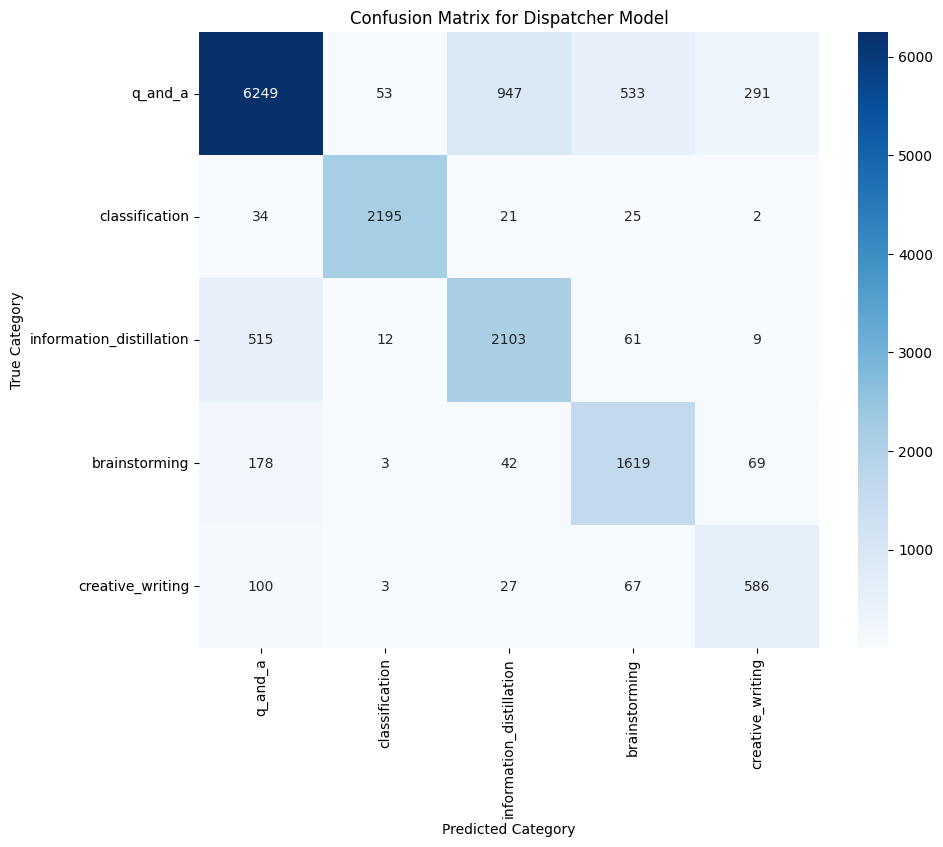

In [53]:
helper_utils.analyze_and_plot_results(partial_results, id2cat)

<a name='6-2'></a>
### 6.2 - Probando el Dispatcher con instrucciones no vistas

Las métricas y las matrices son esenciales, pero la medida definitiva de tu dispatcher de IA es cómo se desempeña en el mundo real. Esta es la prueba final y la más reveladora: confrontar a tu modelo con instrucciones completamente nuevas que nunca ha visto.

Le proporcionarás una variedad de **prompts** y observarás sus clasificaciones en tiempo real. ¿Identifica correctamente una pregunta? ¿Puede detectar una solicitud de resumen? Aquí es donde verás si tu modelo realmente ha aprendido a generalizar.

¡Siéntete libre de añadir tus propias instrucciones personalizadas a la lista de prueba para poner a prueba el dispatcher aún más!

In [54]:
# EDITABLE CELL

test_examples = {
    "q_and_a": [
        {"instruction": "Explain the main stages of the water cycle.", "expected": "q_and_a"},  # Explica las etapas principales del ciclo del agua.
        {"instruction": "What is the historical significance of the Magna Carta?", "expected": "q_and_a"}  # ¿Cuál es la importancia histórica de la Carta Magna?
    ],
    "classification": [
        {"instruction": "Is this movie review positive or negative? 'The plot was amazing and the acting was superb!'", "expected": "classification"},  # ¿Es esta reseña de película positiva o negativa? '¡La trama fue increíble y la actuación excelente!'
        {"instruction": "Is a tomato a fruit or a vegetable?", "expected": "classification"}  # ¿Un tomate es una fruta o una verdura?
    ],
    "information_distillation": [
        {"instruction": "Summarize the main arguments of the article on climate change from this text.", "expected": "information_distillation"},  # Resume los principales argumentos del artículo sobre el cambio climático a partir de este texto.
        {"instruction": "Pull out all the dates mentioned in the following project timeline.", "expected": "information_distillation"}  # Extrae todas las fechas mencionadas en la siguiente línea de tiempo del proyecto.
    ],
    "brainstorming": [
        {"instruction": "Come up with some catchy slogans for a new brand of eco-friendly sneakers.", "expected": "brainstorming"},  # Inventa algunos eslóganes llamativos para una nueva marca de zapatillas ecológicas.
        {"instruction": "Suggest some team-building activities for a company retreat.", "expected": "brainstorming"}  # Sugiere algunas actividades de integración para un retiro empresarial.
    ],
    "creative_writing": [
        {"instruction": "Write a short story about a robot who discovers music.", "expected": "creative_writing"},  # Escribe un cuento corto sobre un robot que descubre la música.
        {"instruction": "Compose a haiku about a rainy day.", "expected": "creative_writing"}  # Compón un haiku sobre un día lluvioso.
    ]
}

In [55]:
# Establecer el modelo en modo de evaluación antes de iniciar el bucle.
trained_finetuned_bert.eval()

print("--- Probando el Dispatcher con nuevas instrucciones ---\n")

# Iterar a través de cada categoría y su lista de ejemplos en el diccionario.
for category, examples in test_examples.items():
    print(f"--- Categoría: {category} ---")
    for example in examples:
        instruction = example["instruction"]
        expected = example["expected"]
        
        # Obtener la predicción del modelo para la instrucción.
        predicted = helper_utils.predict_category(
            model=trained_finetuned_bert,
            tokenizer=bert_tokenizer,
            text=instruction,
            device=device,
            id2cat=id2cat # Pasar el diccionario de mapeo
        )
        
        # Verificar si la predicción fue correcta y establecer el emoji/cadena de resultado.
        if predicted == expected:
            result = "✅ Correcto"
        else:
            result = "❌ Incorrecto"
            
        # Imprimir los resultados en el formato deseado.
        print(f"Instrucción: '{instruction}'")
        print(f"Esperado:     {expected}")
        print(f"Predicho:     {predicted}")
        print(f"Resultado:    {result}\n")

--- Probando el Dispatcher con nuevas instrucciones ---

--- Categoría: q_and_a ---
Instrucción: 'Explain the main stages of the water cycle.'
Esperado:     q_and_a
Predicho:     information_distillation
Resultado:    ❌ Incorrecto

Instrucción: 'What is the historical significance of the Magna Carta?'
Esperado:     q_and_a
Predicho:     information_distillation
Resultado:    ❌ Incorrecto

--- Categoría: classification ---
Instrucción: 'Is this movie review positive or negative? 'The plot was amazing and the acting was superb!''
Esperado:     classification
Predicho:     classification
Resultado:    ✅ Correcto

Instrucción: 'Is a tomato a fruit or a vegetable?'
Esperado:     classification
Predicho:     classification
Resultado:    ✅ Correcto

--- Categoría: information_distillation ---
Instrucción: 'Summarize the main arguments of the article on climate change from this text.'
Esperado:     information_distillation
Predicho:     information_distillation
Resultado:    ✅ Correcto

Instru

## ¡Conclusión: Tu Dispatcher está listo para el servicio!

¡Felicidades! Has construido, ajustado y probado con éxito un **AI Powered Request Dispatcher** completo. Comenzaste con un conjunto de datos crudos y lo transformaste en un modelo de clasificación inteligente y eficiente, capaz de comprender y dirigir la intención del usuario, un componente vital en cualquier sistema de IA moderno.

A lo largo de este camino, has puesto la teoría en práctica. Viste cómo un pipeline de **tokenización**, donde el texto se divide en unidades más pequeñas, y **tensorización**, donde los tokens se convierten en tensores numéricos para el modelo, forma la base de cualquier tarea de NLP. Aprovechaste el poder de un modelo pre-entrenado, **DistilBERT**, ahorrando muchísimo tiempo y utilizando su profundo conocimiento previo del lenguaje.

Lo más importante es que fuiste más allá del entrenamiento básico. Al implementar la **pérdida ponderada** (weighted loss) para abordar el desbalance de clases y aplicar una estrategia de **congelación parcial** (partial freezing), realizaste el tipo de ajuste fino eficiente en parámetros (PEFT) que hace que el desarrollo de modelos de alto rendimiento sea práctico y rentable. No solo construiste un modelo; diseñaste una solución de ingeniería.

El dispatcher que has creado es más que una simple tarea. Representa una pieza fundamental para innumerables aplicaciones avanzadas, desde chatbots sofisticados y motores de búsqueda inteligentes hasta herramientas automatizadas de creación de contenido. Ahora tienes las habilidades y la experiencia práctica para construir los sistemas inteligentes del futuro. ¡Buen trabajo!

## ¿Necesitas una pista sobre los hiperparámetros?

Aunque te animamos encarecidamente a que experimentes primero, si estás atascado, ejecuta la siguiente celda para ver un conjunto de hiperparámetros que te ayudarán a alcanzar las métricas de entrenamiento objetivo.

In [47]:
import base64

encoded_answer = "VHJ5IHRoZSBmb2xsb3dpbmcgaHlwZXJwYXJhbWV0ZXJzOgoKLSBsYXllcnNfdG9fdHJhaW4gPSA0Ci0gbGVhcm5pbmdfcmF0ZSA9IDVlLTUKLSBudW1fZXBvY2hzID0gNQ=="
encoded_answer = encoded_answer.encode('ascii')
answer = base64.b64decode(encoded_answer)
answer = answer.decode('ascii')

print(answer)

Try the following hyperparameters:

- layers_to_train = 4
- learning_rate = 5e-5
- num_epochs = 5
